# **Final Project**
```
Saulo Gil

INF301 – System Modeling and Simulation
Prof. Luiz Henrique Bonani do Nascimento
```


# **Incorporating Mask-Related Transmission Variability into SEIR Models to Analyze COVID-19 Curve-Flattening Strategies**

## - **Introduction**

Viral pandemics are not uncommon in human history, and their occurrence has increased in both frequency and impact over the past two decades, underscoring the vulnerability of an increasingly interconnected world to rapidly spreading pathogens. Since the early 2000s, successive outbreaks caused by novel or re-emerging viruses including severe acute respiratory syndrome coronavirus (SARS-CoV-1) in 2002–2003, the 2009 influenza A(H1N1) pandemic, Middle East respiratory syndrome coronavirus (MERS-CoV), Ebola virus disease, Zika virus infection, and most recently the coronavirus disease 2019 (COVID-19) pandemic driven by SARS-CoV-2, have repeatedly tested national health systems and the global governance architecture for health security (1-3). Although forecasting the spread of viruses is challenging, we can learn from past pandemics to better prepare for future epidemics. 

In this scenario, mathematical models can be used to simulate and better understand the spread of infectious diseases. Among these, the SEIR framework is one of the most widely used to represent the dynamics of viral epidemics and pandemics in human populations. The SEIR model divides the population into four compartments: Susceptible ($S$), who are at risk of infection; Exposed ($E$), who have been infected but are not yet infectious (i.e., incubation period); Infectious ($I$), who can transmit the pathogen; and Recovered ($R$), who are no longer infectious and are assumed to have acquired immunity. Transitions between compartments are typically described by a system of differential equations that can derive the corresponding difference equations (using Euler Method) to simulate the biological system by key parameters: the transmission rate ($\lambda$), which controls how quickly susceptible individuals become exposed; the progression rate from exposed to infectious ($\sigma$), inversely related to the incubation period; and the recovery rate ($\delta$), inversely related to the duration of infectiousness (4). By adjusting these parameters and initial conditions, SEIR models enable researchers to explore hypothetical scenarios such as the impact of mask-based interventions and to generate insights that can inform preparedness and response planning for future epidemics.

Thus, we simulated the spread of disease by modeling COVID-19 transmission during the first wave (2020–2023), incorporating data-informed variations in the transmission rate associated with mask use, in order to examine strategies for flattening the infection curve.

## - **Methods**

For modeling the spread of COVID-19 transmission during the first wave (2020–2023), we considered four groups of individuals: 

- those **susceptible** to the disease ($S$);

- those **exposed** to the disease ($E$);

- those **infected** ($I$) and;

- those who have **recovered** ($R$).

Other key quantities in the model include the infection rate ($\lambda$), recovery rate ($\delta$), incubation rate ($\sigma$), and the total population size ($N$).

Using these variables, the system of differential equations can be written as follows:

$$ \begin{equation}
   \left\{
   \begin{array}{rl}
   \frac{dS}{dt} & = & \frac{-\lambda S I}{N}\\
   \\
   \frac{dE}{dt} & = & \frac{-\lambda S I}{N} - \sigma E\\
   \\
   \frac{dI}{dt} & = & \sigma E - \delta I\\ 
   \\   
   \frac{dR}{dt} & = & \delta I
   \end{array}
   \right.
   \end{equation} $$  

where:
 - $S(t)$ = number of susceptible individuals;

 - $E(t)$ = number of exposed individuals (infected but not yet infectious);

 - $I(t)$ =  number of infectious individuals;

 - $R(t)$ = number of recovered individuals;
 
 - $N=S+E+I+R$ = size of population;
 
 - $\lambda$ = transmission (infection) rate;

 - $\delta$ = recovery rate;

 - $\sigma$ = incubation rate, i.e., the rate at which exposed individuals become infectious (approximately the inverse of the mean incubation period);
 

From these differential equations, we can derive the corresponding difference equations using the Euler method to numerically simulate the behavior of the biological system:

$$ \begin{equation}
   \left\{
   \begin{array}{rl}
   S(t + \Delta t) & = & S(t) - \frac{\lambda}{N}S(t)I(t)\Delta t \\
   \\
   E(t + \Delta t) & = & E(t) + \Bigg(\frac{\lambda}{N}S(t)I(t) - \sigma E(t)\Bigg)\Delta t  \\
   \\
   I(t + \Delta t) & = & I(t) + \Bigg(\sigma E(t) - \delta I(t)\Bigg)\Delta t \\
   \\
   R(t + \Delta t) & = & R(t) + \delta I(t) \Delta t
   \end{array}
   \right.
   \end{equation} $$


where $\lambda$ is the transmission rate, $\sigma$ is the incubation rate, $\delta$ is the recovery rate, and $𝑁=𝑆(𝑡)+𝐸(𝑡)+𝐼(𝑡)+𝑅(𝑡)$

Now, we can simulate a the spread of a disease.

To simulate the transmission rate using the SEIR (Susceptible, Exposed, Infectious, Recovered) model, the following parameters were utilized: the rate of infection, the incubation period, the recovery rate, and the transmission probability. These parameters were derived from previous data collected during prior studies. 

The values for each parameter is showed above:
| Parameter               | Symbol | Value          | Description                                  |                  |
|-------------------------|--------|----------------|----------------------------------------------| ---------------- |
| Infection Rate - No mask         | $\lambda_{\text{No mask}}$      | 0.59            | Rate at which susceptible individuals become exposed | reference |
| Infection Rate - Cloth mask        | $\lambda_{\text{Cloth mask}}$      | 0.42            | Rate at which susceptible individuals become exposed | reference |
| Infection Rate - Cirurgical mask        | $\lambda_{\text{Cirurgical mask}}$      | 0.30            | Rate at which susceptible individuals become exposed | reference |
| Infection Rate - N95       | $\lambda_{\text{N95}}$      | 0.18            | Rate at which susceptible individuals become exposed | reference |
| Incubation Rate       | $\sigma$      | 1/5 days     | Rate at which exposed individuals become infectious | reference |
| Recovery Rate         | $\delta$      | 1/10 days      | Rate at which infectious individuals recover | reference |
| Sample Size (populations of SP)        | $N$      | 11.9 million      | Populations of SP | reference |


The simulation was implemented in Python, using libraries such as NumPy for numerical computations and Matplotlib for visualization. The model was run over a specified time period, with initial conditions set for the number of susceptible, exposed, infectious, and recovered individuals.

The simulation was run for a total of 400 days, with a time step of 1 day. 

The initial conditions were set as follows: 999 susceptible individuals, 1 exposed individual, 0 infectious individuals, and 0 recovered individuals.

## - **Results**

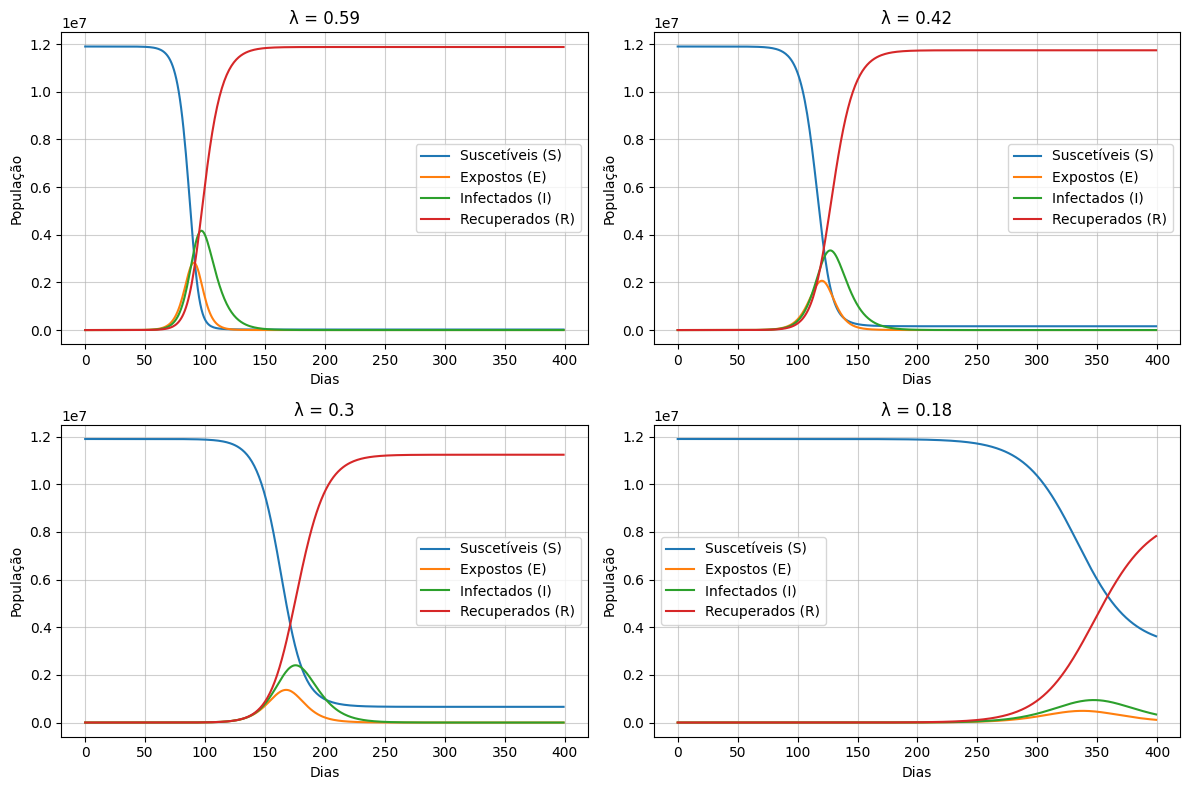

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1.19e7                           # total population
lambdas = [0.59, 0.42, 0.30, 0.18]   # transmission rates (no mask, cloth, surgical, N95)
delta = 0.10                          # recovery rate (δ) ~ 10 days (1/10)
sigma = 0.20                          # incubation rate (σ) ~ 5 days (1/5)
Delta_t = 1                          # time step (days) 
T = 400                              # total time (days)

# Time vector
t = np.arange(0, T, Delta_t)

# List to store all I curves
all_I = []

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for idx, lambda_ in enumerate(lambdas):

    # Arrays for S, E, I, R
    S = np.zeros(len(t))
    E = np.zeros(len(t))
    I = np.zeros(len(t))
    R = np.zeros(len(t))

    # Initial conditions
    S[0] = N - 1 # First case in SP - 26 de fevereiro de 2020
    E[0] = 0
    I[0] = 1
    R[0] = 0

    # Euler iteration of discrete SEIR model
    for k in range(len(t) - 1):
        S[k+1] = S[k] - (lambda_ / N) * S[k] * I[k] * Delta_t    
        E[k+1] = E[k] + ((lambda_ / N) * S[k] * I[k] - sigma * E[k]) * Delta_t
        I[k+1] = I[k] + (sigma * E[k] - delta * I[k]) * Delta_t
        R[k+1] = R[k] + delta * I[k] * Delta_t

    # Save I curve
    all_I.append(I)

    # Plot SEIR subplots
    ax = axs[idx]
    ax.plot(t, S, label="Suscetíveis (S)")
    ax.plot(t, E, label="Expostos (E)")
    ax.plot(t, I, label="Infectados (I)")
    ax.plot(t, R, label="Recuperados (R)")
    ax.set_title(f"λ = {lambda_}")
    ax.set_xlabel("Dias")
    ax.set_ylabel("População")
    ax.legend()
    ax.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

The four panels show the temporal evolution of the SEIR compartments for decreasing transmission rates ($\lambda$ = 0.59, 0.42, 0.30, 0.18), which represent, respectively, no mask use, cloth masks, surgical masks, and N95/PFF2 masks. 

In the scenario without masks ($\lambda$ = 0.59), the number of infected individuals (I) rises very rapidly, producing an early and high peak, while the susceptible population (S) declines abruptly and the recovered compartment (R) quickly approaches the total population. 

With cloth masks ($\lambda$ = 0.42), the epidemic still grows quickly, but the peak of infected individuals (I) is already lower and slightly delayed. As more effective masks are introduced, i.e., surgical ($\lambda$ = 0.30) and especially N95/PFF2 ($\lambda$ = 0.18), both the exposed (E) and infected (I) curves become progressively lower and more spread out over time. 

In the N95 condition, the infection curve is clearly flattened and delayed, indicating slower transmission, a substantially reduced maximum number of simultaneous infections, and consequently a lower potential burden on the healthcare system.


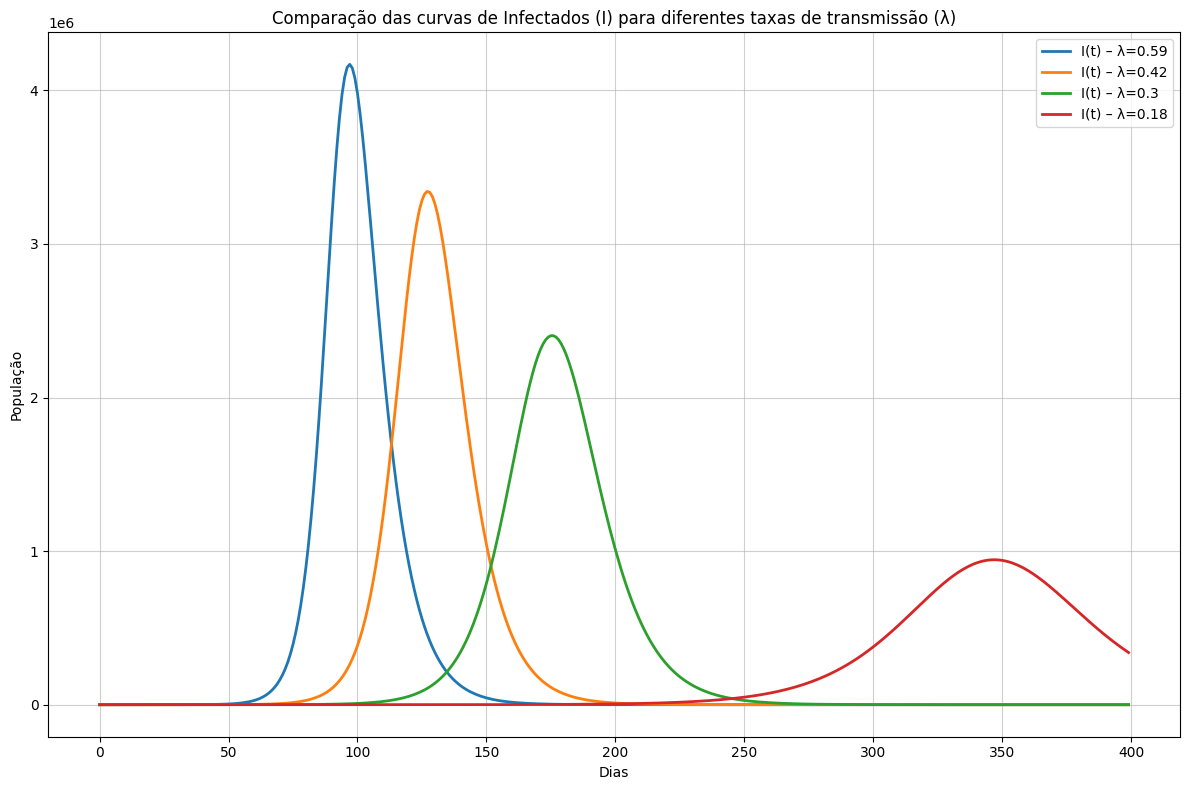

In [14]:
# All Infected Curves
plt.figure(figsize=(12, 8))

for I_curve, lambda_ in zip(all_I, lambdas):
    # Curva total de infectados
    plt.plot(t, I_curve, label=f"I(t) – λ={lambda_}", linewidth=2)

plt.title("Comparação das curvas de Infectados (I) para diferentes taxas de transmissão (λ)")
plt.xlabel("Dias")
plt.ylabel("População")
plt.grid(True, alpha=0.6)

# # Linha de capacidade de leitos
# plt.hlines(y=121896, xmin=0, xmax=max(t), color='r', linestyle='--',
#            label='Número de leitos de urgência/emergência em SP')

plt.legend()
plt.tight_layout()
plt.show()

To demonstrate the transmission rate through mask use, I plotted only the infection curves in just a figure. The figure displays the isolated infection curves I(t) for the four transmission rates $\lambda$=0.59,0.42,0.30,0.18, representing no mask, cloth, surgical, and N95/PFF2 use, respectively. 

As shown in figure, as $\lambda$ decreases the peak number of infected individuals becomes progressively lower and occurs later in time. Again, the scenario without masks ($\lambda$=0.59) exhibits a very sharp, early peak, whereas the N95/PFF2 scenario ($\lambda$=0.18) shows a much smaller and delayed peak. Therefore, this simulation highlights the potential benefits of mask use, particularly N95/PFF2 masks, in flattening the epidemic curve and thereby reducing the maximum instantaneous burden on health-care services

Although the total number of infected individuals is important, severe cases are critical because they require hospitalization and can rapidly push health systems to (or beyond) their maximum capacity. In this sense, I estimated the number of severe cases as 15% of all COVID-19 infections, in line with previous reports. 

Furthermore, using data from the National Registry of Health Establishments (CNES - Cadastro Nacional de Estabelecimentos de Saúde) available on basedosdados.org, I obtained the number of rest/observation beds in emergency units as a indicator of the health-care system’s capacity to manage severe COVID-19 cases in São Paulo. For this purpose, I performed an SQL query in BigQuery (Google Cloud) on the basedosdados.br_ms_cnes.estabelecimento table using the code shown below (Figure).

```sql
SELECT
  SUM(
    dados.quantidade_leito_repouso_feminino_urgencia +
    dados.quantidade_leito_repouso_masculino_urgencia +
    dados.quantidade_leito_repouso_indiferenciado_urgencia +
  ) AS soma_total_leitos
FROM
    `basedosdados.br_ms_cnes.estabelecimento` AS dados
WHERE dados.sigla_uf = 'SP'
    AND dados.ano = '2020'
```

<p align="center">
  <img src="img/sql_query.jpeg" width="1000"/>
</p>

Then, we added a horizontal dashed line indicating the number of rest/observation beds in emergency units, in order to assess whether mask use could help reduce the burden on the health-care system.

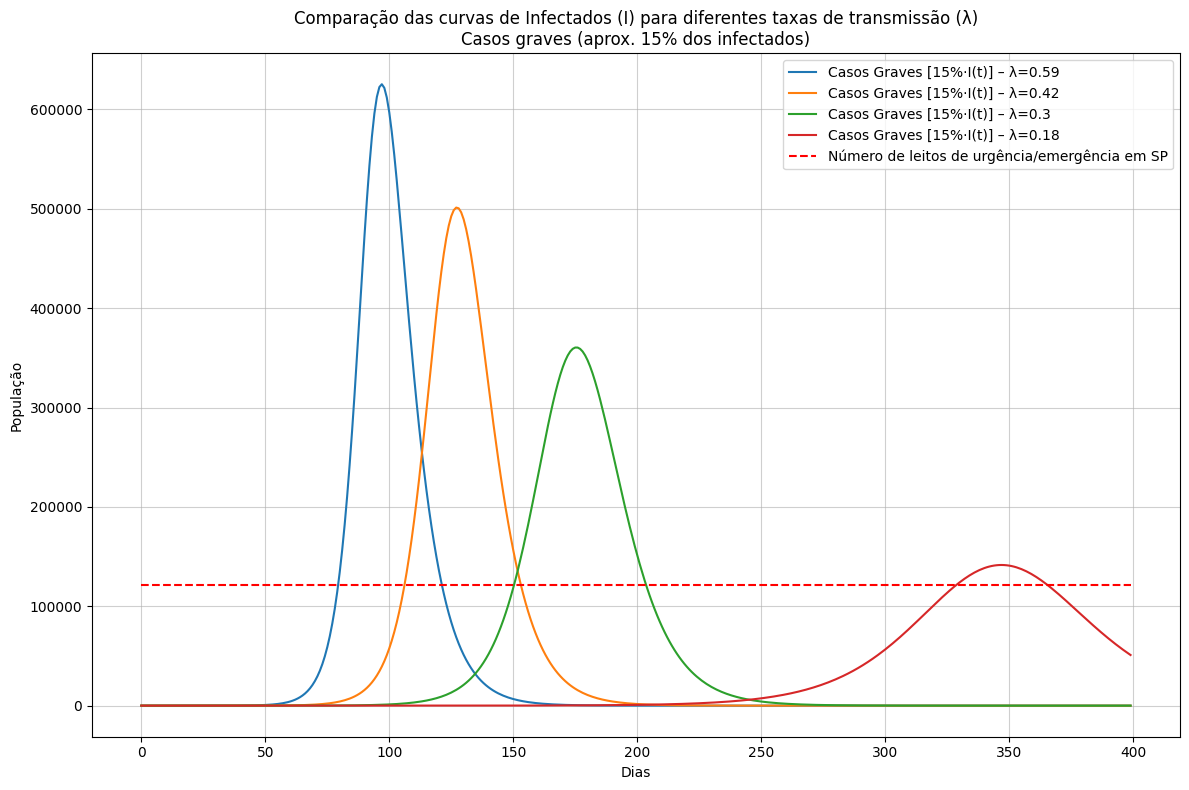

In [15]:
# All Infected Curves
plt.figure(figsize=(12, 8))

for I_curve, lambda_ in zip(all_I, lambdas):
    # 15% dos infectados (ex.: casos que vão desenvolver sintomas graves)
    I_curve_15 = 0.15 * I_curve
    # Curva de 15% dos infectados
    plt.plot(t, I_curve_15, label=f"Casos Graves [15%·I(t)] – λ={lambda_}")

plt.title("Comparação das curvas de Infectados (I) para diferentes taxas de transmissão (λ)\nCasos graves (aprox. 15% dos infectados)")
plt.xlabel("Dias")
plt.ylabel("População")
plt.grid(True, alpha=0.6)

# Linha de capacidade de leitos
plt.hlines(y=121896, xmin=0, xmax=max(t), color='r', linestyle='--',
           label='Número de leitos de urgência/emergência em SP')

plt.legend()
plt.tight_layout()
plt.show()

The simulation shows the estimated number of severe COVID-19 cases ($\approx$ 15% of infections) over time for the four transmission rates ($\lambda$ = 0.59, 0.42, 0.30, 0.18), together with a horizontal dashed line representing the total number of rest/observation beds in emergency units in São Paulo. In the no-mask and cloth-mask scenarios ($\lambda$ = 0.59 and 0.42), the peaks of severe cases are very high and occur early, far exceeding the available bed capacity. With surgical masks ($\lambda$ = 0.30), the peak is lower and delayed, but still substantially above the capacity line. In contrast, under the N95/PFF2 scenario ($\lambda$ = 0.18), the peak of severe cases is much smaller, occurs later in the epidemic, and lies close to the dashed capacity line. 

This pattern indicates that only the high-efficiency N95/PFF2 masks are capable of flattening the curve of severe cases to a level approaching the existing emergency bed capacity, thereby markedly reducing the risk of health-system overload.


## - **Conclusion**

Taken together, the SEIR simulations of the first COVID-19 wave suggest that reductions in the transmission rate associated with mask use substantially modify epidemic dynamics. As $\lambda$ decreases from values representing no mask use to cloth, surgical, and finally N95/PFF2 masks, both the total number of infections and the peak prevalence of active cases are progressively reduced and delayed, demonstrating a clear flattening of the epidemic curve. 

When severe cases are approximated as 15% of infections and compared with the number of rest/observation beds available in emergency units in São Paulo, only the N95/PFF2 scenario produces a peak of severe disease that approaches, rather than vastly exceeds, the existing capacity. 

Although based on a simplified model and several assumptions, these findings reinforce the importance of high-efficacy masks as a non-pharmaceutical intervention capable of mitigating health-system overload during viral pandemics, particularly in the early phases when vaccines and specific treatments may not yet be widely available.


## - **References**

1.	Bhadoria P, Gupta G, Agarwal A. Viral Pandemics in the Past Two Decades: An Overview. J Family Med Prim Care. 2021;10(8):2745-50.

2.	Morens DM, Fauci AS. Emerging Pandemic Diseases: How We Got to COVID-19. Cell. 2020;182(5):1077-92.

3.	Wilder-Smith A. COVID-19 in comparison with other emerging viral diseases: risk of geographic spread via travel. Trop Dis Travel Med Vaccines. 2021;7(1):3.

4.	Liu X. Analytical solution of l-i SEIR model-Comparison of l-i SEIR model with conventional SEIR model in simulation of epidemic curves. PLoS One. 2023;18(6):e0287196.
